In [1]:
import numpy as np
import pandas as pd
import polars as pl
import torch

import matplotlib.pyplot as plt
import seaborn as sns


import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from scipy.stats import zscore
from tqdm import tqdm
from functools import partial


# home-grown
import utils as ut
import model as mod
import lazydata as lzdt

In [2]:
pd.options.display.max_columns = 60

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
df_mm, dict_colnames = ut.load_mm_dataset("full")

In [5]:
df_use = df_mm
dict_info = dict_colnames

In [6]:
df_use[dict_info["l_colnames_single_zscale"]] = df_use[dict_info["l_colnames_single_zscale"]].apply(zscore)

In [7]:
df_use = ut.shift_y(df_use)

drop button smashers

In [13]:
df_include = df_use.groupby("sid_unique")["right_picked"].agg(["mean", "count"]).reset_index().query("mean != 0 and mean != 1").sort_values("count")

In [16]:
df_use = pd.merge(df_include.drop(columns=["mean", "count"]), df_use, how="inner", on="sid_unique")

## Predict using sklearn Boosted Classifier

In [18]:
from sklearn.linear_model import LogisticRegression
from joblib import Parallel, delayed

In [21]:
df_cluster_assignment = df_use[["sid_unique", "country_cluster"]].drop_duplicates()

In [23]:
df_sample = df_cluster_assignment#.sample(1000, random_state=908)

In [24]:
df_use["oldmen_rml"] = df_use["right_oldman"] - df_use["left_oldman"]
df_use["oldwomen_rml"] = df_use["right_oldwoman"] - df_use["left_oldwoman"]

In [25]:
X_train = df_use[["sid_unique", "oldmen_rml", "oldwomen_rml"]]
y_train = df_use[["sid_unique", "right_picked"]]

In [26]:
def fit_subject(current_id):
    m = LogisticRegression()
    X = X_train.query(f"""sid_unique == '{current_id}'""").drop(columns=["sid_unique"])
    y = np.ravel(y_train.query(f"""sid_unique == '{current_id}'""").drop(columns=["sid_unique"]))
    m.fit(X, y)
    return [current_id, np.round(m.coef_[0, 0], 2), np.round(m.coef_[0, 1], 2)]

In [27]:
ids_subset = df_sample["sid_unique"].to_list()

In [39]:
import os
import pickle

In [42]:
is_fit = False

In [43]:
if is_fit:
    t_start = os.times()[1]
    l_coefs = list(map(fit_subject, ids_subset))
    n_seconds_serial = os.times()[1] - t_start
    with open("data/variability-in-age-results.pickle", "wb") as f:
        pickle.dump(l_coefs, f)
else:
    with open("data/variability-in-age-results.pickle", "rb") as f:
        l_coefs = pickle.load(f)

In [44]:
print(f"""time serial: {n_seconds_serial}\n""")

time serial: 22.939999999999998



In [45]:
df_betas = pd.DataFrame(np.array(l_coefs))
df_betas.columns=["sid_unique", "oldmen_rml", "oldwomen_rml"]

In [46]:
df_betas = pd.merge(df_betas, df_cluster_assignment, how="left", on="sid_unique")

In [47]:
df_betas_long = df_betas.melt(id_vars=["sid_unique", "country_cluster"]).sort_values(["sid_unique", "variable"])
df_betas_long["value"] = np.round(df_betas_long["value"].astype(np.float16), 2)

In [48]:
def sterr(x):
    return np.std(x)/np.sqrt(len(x))

In [49]:
df_means = df_betas_long.groupby(["country_cluster", "variable"])["value"].agg(["count", "mean", sterr]).reset_index()

/tmp/ipykernel_886583/3852035784.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Old Men", "Old Women"], fontsize=12)
/tmp/ipykernel_886583/3852035784.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


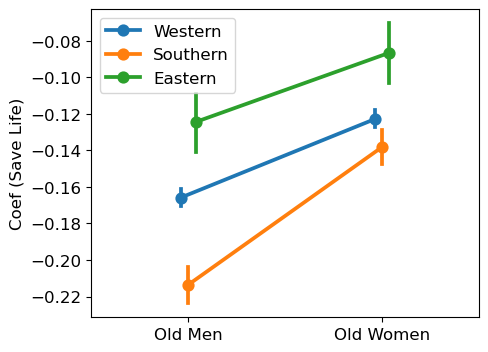

In [54]:
f, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.pointplot(data=df_betas_long, x="variable", y="value", hue="country_cluster", errorbar=("ci", 95), dodge=True)
ax.set_xticklabels(["Old Men", "Old Women"], fontsize=12)
ax.set_ylabel("Coef (Save Life)", fontsize=12)
ax.set_xlabel("")
ax.legend(title="", fontsize=12)

ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)


plt.savefig("figures/variability-age-means.pdf")

In [98]:
np.corrcoef(df_betas["oldmen_rml"].astype(np.float16), df_betas["oldwomen_rml"].astype(np.float16))

array([[ 1.        , -0.02218691],
       [-0.02218691,  1.        ]])

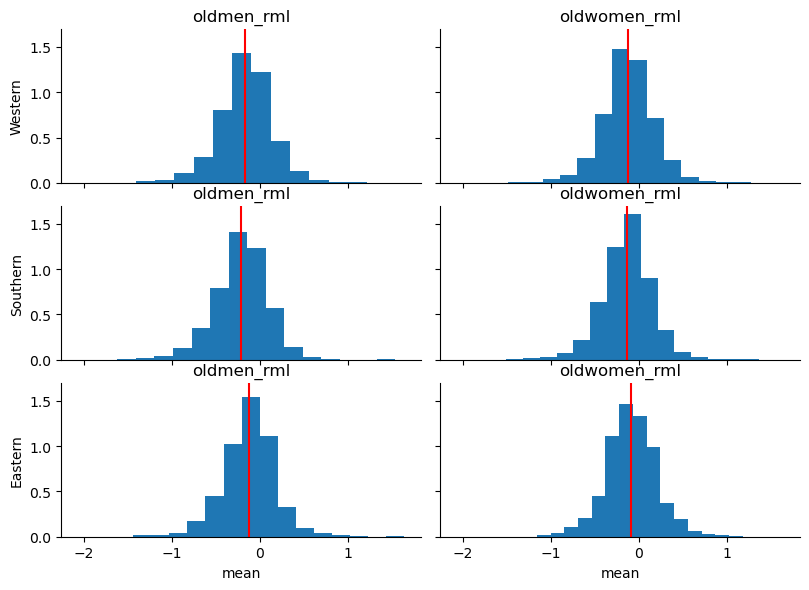

In [99]:
df_betas_long["source"] = "A"
df_means["source"] = "B"
df_means["sid_unique"] = None

df_all = pd.concat([df_betas_long, df_means], ignore_index=True)
 
def hist_func(data, x, bins, **kwargs):
    ax = kwargs.get("ax", plt.gca())
    subset = data[data["sid_unique"].notna()]
    ax.hist(subset[x], bins=bins, density=True)

def vline_func(data, x, **kwargs):
    ax = kwargs.get("ax", plt.gca())
    subset = data[data["sid_unique"].isna()]
    for val in subset[x]:
        ax.axvline(val, color="red")

g = sns.FacetGrid(df_all, col="variable", row="country_cluster", height=2, aspect=2, margin_titles=True)
g.set_titles(col_template="{col_name}", row_template="")

g.map_dataframe(hist_func, x="value", bins=15)
g.map_dataframe(vline_func, x="mean")

# After all your g.map_dataframe(...) calls
# After all your g.map_dataframe(...) calls
# After all g.map_dataframe(...) calls

for (row_val, col_val), ax in g.axes_dict.items():
    # Column titles
    ax.set_title(col_val)

    # Row titles on the left only
    if col_val == g.col_names[0]:
        ax.set_ylabel(row_val)
    else:
        ax.set_ylabel("")

plt.savefig("figures/variability-age-histogram.pdf")

In [83]:
df_betas_long["value_above_0"] = df_betas_long["value"] > 0
df_betas_long["value_below_0"] = df_betas_long["value"] <= 0

In [84]:
df_betas_long.groupby(["variable", "country_cluster"])[["value_above_0", "value_below_0"]].agg(["count", "sum", "mean"]).reset_index()

variable   cluster value_above_0                 value_below_0        \
                                  count   sum      mean         count   sum   
0    oldmen_rml   Eastern           309   102  0.330097           309   207   
1    oldmen_rml  Southern           808   176  0.217822           808   632   
2    oldmen_rml   Western          4021  1012  0.251679          4021  3009   
3  oldwomen_rml   Eastern           309   105  0.339806           309   204   
4  oldwomen_rml  Southern           808   208  0.257426           808   600   
5  oldwomen_rml   Western          4021  1156  0.287491          4021  2865   

             
       mean  
0  0.669903  
1  0.782178  
2  0.748321  
3  0.660194  
4  0.742574  
5  0.712509